# Sentiment Analysis — US Politicians Wikipedia Articles

For each question we report descriptive stats, a statistical test, and a compact plot.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
from scipy import stats
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False})

df = pd.read_csv("tokenized_wikipage.csv")
print(f"Loaded {len(df)} politicians")
print(df[["name","party","gender","degree"]].head())


Loaded 6136 politicians
              name       party  gender  degree
0     Barack Obama    Democrat    male      32
1  Valerie Jarrett    Democrat  female      10
2     Donald Trump  Republican    male      10
3   Stephen Miller  Republican    male      41
4        Karl Rove  Republican    male      43


In [3]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not text or not isinstance(text, str):
        return None
    return analyzer.polarity_scores(text)["compound"]

# Only compute if not already present
if "sentiment_score" not in df.columns or df["sentiment_score"].isna().all():
    df["sentiment_score"] = df["body_text"].apply(get_sentiment)

df["sentiment_abs"] = df["sentiment_score"].abs()

print(f"Articles with sentiment : {df['sentiment_score'].notna().sum()}")
print(f"Overall mean            : {df['sentiment_score'].mean():.4f}")
print(f"Overall std             : {df['sentiment_score'].std():.4f}")
print(f"Near-zero (|s| < 0.05)  : {(df['sentiment_abs'] < 0.05).sum()} "
      f"({(df['sentiment_abs'] < 0.05).mean()*100:.1f}%)")


Articles with sentiment : 6136
Overall mean            : 0.3704
Overall std             : 0.7880
Near-zero (|s| < 0.05)  : 131 (2.1%)


## Statistical test choice

Sentiment scores are **continuous but not normally distributed** (VADER compounds are bounded [-1, 1] and tend to pile up near 0). We therefore use:

- **Mann-Whitney U** (2 groups) — non-parametric, no normality assumption
- **Kruskal-Wallis** (3+ groups) — non-parametric generalisation of ANOVA
- **Spearman ρ** (correlations) — non-parametric rank correlation

If Kruskal-Wallis is significant we run pairwise Mann-Whitney with Bonferroni correction.


## Q1 — Does Wikipedia neutrality hold?

If Wikipedia is truly neutral, the mean compound score should be near 0 and not significantly different from 0.

=== Q1: Is overall sentiment neutral (≈0)? ===
  Mean ± std          : 0.3704 ± 0.7880
  Median              : 0.8918
  t-test vs 0         : t=36.823  p=2.3037e-268
  Wilcoxon signed-rank: W=4429225.0  p=3.6927e-264

→ Sentiment is significantly different from 0 — Wikipedia is not perfectly neutral


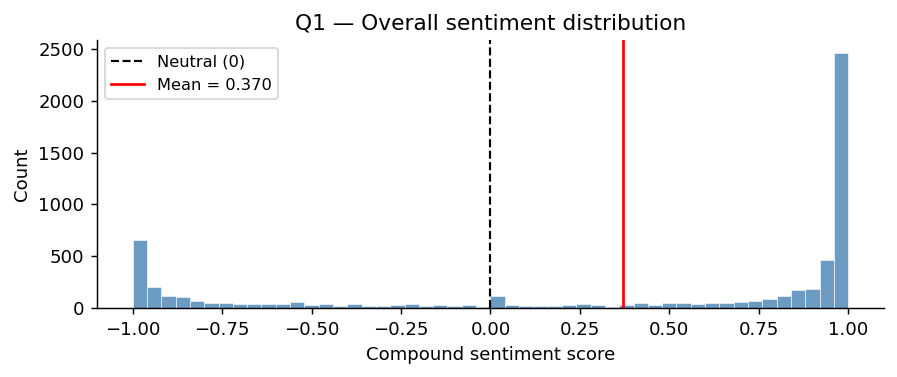

In [4]:
scores = df["sentiment_score"].dropna()

# One-sample t-test against 0 (also report non-parametric Wilcoxon signed-rank)
t_stat, t_p = stats.ttest_1samp(scores, 0)
w_stat, w_p = stats.wilcoxon(scores)

print("=== Q1: Is overall sentiment neutral (≈0)? ===")
print(f"  Mean ± std          : {scores.mean():.4f} ± {scores.std():.4f}")
print(f"  Median              : {scores.median():.4f}")
print(f"  t-test vs 0         : t={t_stat:.3f}  p={t_p:.4e}")
print(f"  Wilcoxon signed-rank: W={w_stat:.1f}  p={w_p:.4e}")
print()
if t_p < 0.05:
    print("→ Sentiment is significantly different from 0 — Wikipedia is not perfectly neutral")
else:
    print("→ Cannot reject neutrality — mean sentiment is indistinguishable from 0")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(scores, bins=50, color="steelblue", alpha=0.8, edgecolor="white", linewidth=0.4)
ax.axvline(0,             color="black", linewidth=1.2, linestyle="--", label="Neutral (0)")
ax.axvline(scores.mean(), color="red",   linewidth=1.5, linestyle="-",
           label=f"Mean = {scores.mean():.3f}")
ax.set_xlabel("Compound sentiment score")
ax.set_ylabel("Count")
ax.set_title("Q1 — Overall sentiment distribution")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("q1_neutrality.png", dpi=150, bbox_inches="tight")
plt.show()


## Q2 — Does sentiment differ by party?

=== Q2: Sentiment by party ===
Party                n     mean    median     std
  Democrat        3185   0.3821    0.9070  0.7852
  Republican      2724   0.3521    0.8762  0.7954
  Other            227   0.4261    0.8519  0.7334
Kruskal-Wallis: H=2.692  p=2.6033e-01
Pairwise Mann-Whitney (Bonferroni α=0.0167):
  Democrat vs Republican  : U=4442022  p=1.1143e-01  ✗ not significant
  Democrat vs Other       : U=360488  p=9.4388e-01  ✗ not significant
  Republican vs Other       : U=300295  p=4.7160e-01  ✗ not significant


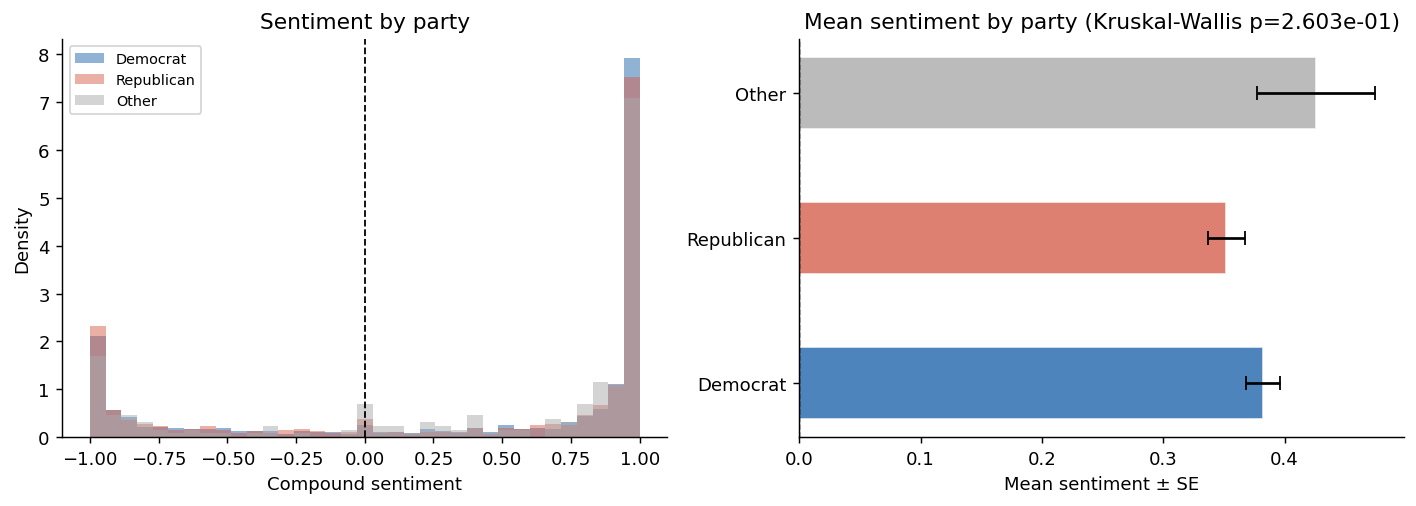

In [5]:
parties = ["Democrat", "Republican", "Other"]
groups  = [df[df["party"] == p]["sentiment_score"].dropna() for p in parties]

# Kruskal-Wallis across all parties
h_stat, h_p = stats.kruskal(*groups)

print("=== Q2: Sentiment by party ===")
print(f"{'Party':15s}  {'n':>5}  {'mean':>7}  {'median':>8}  {'std':>6}")
for p, g in zip(parties, groups):
    print(f"  {p:13s}  {len(g):5d}  {g.mean():7.4f}  {g.median():8.4f}  {g.std():6.4f}")
print(f"Kruskal-Wallis: H={h_stat:.3f}  p={h_p:.4e}")

# Pairwise Mann-Whitney with Bonferroni
pairs = [("Democrat","Republican"), ("Democrat","Other"), ("Republican","Other")]
alpha_bonf = 0.05 / len(pairs)
print(f"Pairwise Mann-Whitney (Bonferroni α={alpha_bonf:.4f}):")
for p1, p2 in pairs:
    g1 = df[df["party"] == p1]["sentiment_score"].dropna()
    g2 = df[df["party"] == p2]["sentiment_score"].dropna()
    u, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    sig = "✓ significant" if p < alpha_bonf else "✗ not significant"
    print(f"  {p1} vs {p2:12s}: U={u:.0f}  p={p:.4e}  {sig}")

COLORS = {"Democrat": "#2166ac", "Republican": "#d6604d", "Other": "#aaaaaa"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for p, g, color in zip(parties, groups, COLORS.values()):
    axes[0].hist(g, bins=35, alpha=0.5, color=color, label=p, density=True)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("Compound sentiment"); axes[0].set_ylabel("Density")
axes[0].set_title("Sentiment by party"); axes[0].legend(fontsize=8)

means   = [g.mean() for g in groups]
sems    = [g.sem()  for g in groups]
axes[1].barh(parties, means, xerr=sems, color=list(COLORS.values()),
             alpha=0.8, edgecolor="white", height=0.5,
             error_kw=dict(ecolor="black", capsize=4))
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Mean sentiment ± SE")
axes[1].set_title(f"Mean sentiment by party (Kruskal-Wallis p={h_p:.3e})")

plt.tight_layout()
plt.savefig("q2_party_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


## Q3 — Does sentiment differ by gender?

=== Q3: Sentiment by gender ===
Gender          n     mean    median     std
  male       4893   0.3494    0.8753  0.7955
  female     1238   0.4540    0.9306  0.7516
Mann-Whitney U: U=2855774  p=1.8749e-03
→ Significant gender difference in sentiment


/var/folders/pt/srr73kjx1pdbnpwylcyp844r0000gn/T/ipykernel_63023/200900275.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([g_male, g_fem], labels=genders, patch_artist=True,


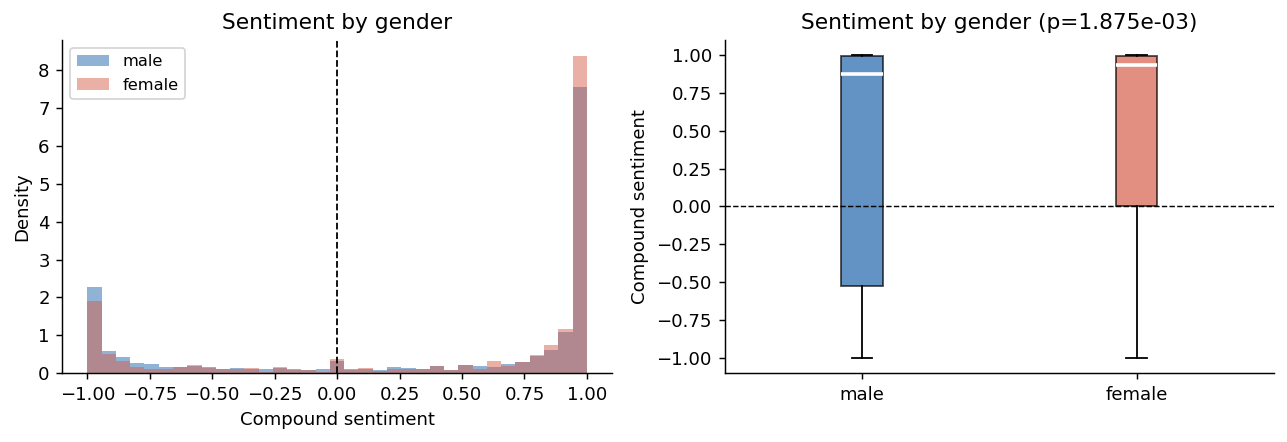

In [6]:
genders = ["male", "female"]
g_male  = df[df["gender"] == "male"]["sentiment_score"].dropna()
g_fem   = df[df["gender"] == "female"]["sentiment_score"].dropna()

u_stat, u_p = stats.mannwhitneyu(g_male, g_fem, alternative="two-sided")

print("=== Q3: Sentiment by gender ===")
print(f"{'Gender':10s}  {'n':>5}  {'mean':>7}  {'median':>8}  {'std':>6}")
for label, g in zip(genders, [g_male, g_fem]):
    print(f"  {label:8s}  {len(g):5d}  {g.mean():7.4f}  {g.median():8.4f}  {g.std():6.4f}")
print(f"Mann-Whitney U: U={u_stat:.0f}  p={u_p:.4e}")
if u_p < 0.05:
    print("→ Significant gender difference in sentiment")
else:
    print("→ No significant gender difference in sentiment")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for label, g, color in zip(genders, [g_male, g_fem], ["#2166ac","#d6604d"]):
    axes[0].hist(g, bins=35, alpha=0.5, color=color, label=label, density=True)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_xlabel("Compound sentiment"); axes[0].set_ylabel("Density")
axes[0].set_title("Sentiment by gender"); axes[0].legend(fontsize=9)

axes[1].boxplot([g_male, g_fem], labels=genders, patch_artist=True,
                medianprops=dict(color="white", linewidth=2),
                boxprops=dict(alpha=0.7))
boxes = axes[1].patches
for box, color in zip(boxes, ["#2166ac","#d6604d"]):
    box.set_facecolor(color)
axes[1].set_ylabel("Compound sentiment")
axes[1].set_title(f"Sentiment by gender (p={u_p:.3e})")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.savefig("q3_gender_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


## Q4 — Does network centrality predict neutrality?

Hypothesis: more central politicians (higher degree/PageRank) have more carefully edited, more neutral articles.

=== Q4: Centrality vs sentiment ===
  Spearman ρ(degree, sentiment)   = +0.332  p=1.6884e-157
 Significant positive correlation: higher degree - more extreme


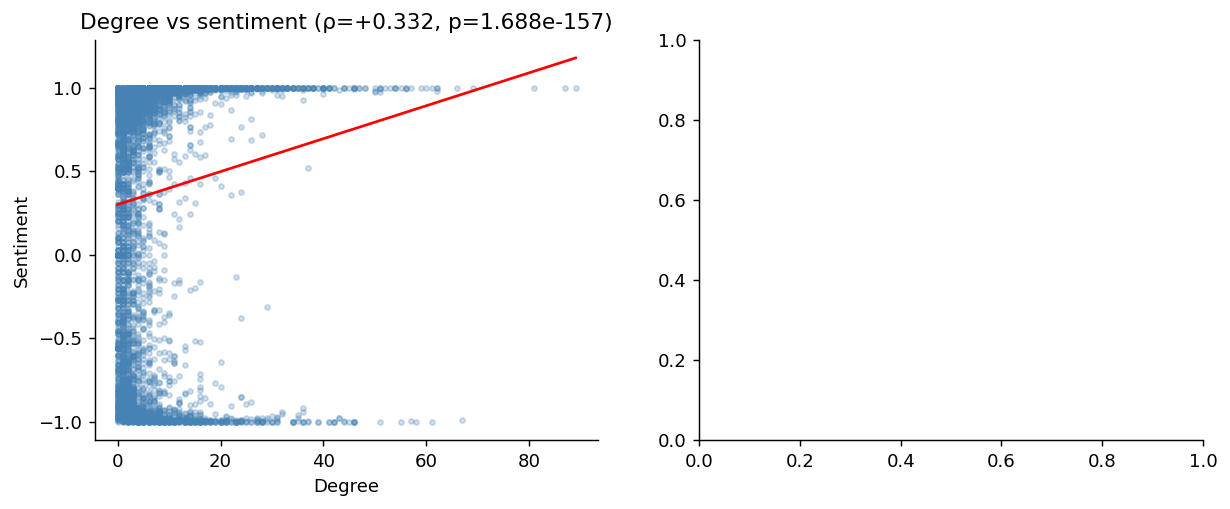

In [8]:
from scipy.stats import spearmanr

valid = df[df["sentiment_score"].notna() & df["degree"].notna()].copy()

r_deg,  p_deg  = spearmanr(valid["degree"], valid["sentiment_score"])
print("=== Q4: Centrality vs sentiment ===")
print(f"  Spearman ρ(degree, sentiment)   = {r_deg:+.3f}  p={p_deg:.4e}")


if p_deg < 0.05:
    direction = "negative" if r_deg < 0 else "positive"
    print(f" Significant {direction} correlation: "
          f"{'higher degree - more neutral' if r_deg < 0 else 'higher degree - more extreme'}")
else:
    print(" No significant correlation between centrality and sentiment neutrality")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(valid["degree"], valid["sentiment_score"],
                alpha=0.25, s=8, color="steelblue")
# Trend line
z = np.polyfit(valid["degree"], valid["sentiment_score"], 1)
xr = np.linspace(valid["degree"].min(), valid["degree"].max(), 100)
axes[0].plot(xr, np.polyval(z, xr), color="red", linewidth=1.5)
axes[0].set_xlabel("Degree"); axes[0].set_ylabel("Sentiment")
axes[0].set_title(f"Degree vs sentiment (ρ={r_deg:+.3f}, p={p_deg:.3e})")
plt.show()


## Q5 — Does sentiment differ by position tier?

=== Q5: Sentiment by position tier ===
Position                       n     mean    median
  President                    8   0.2469    0.9867
  Vice President              11   0.9873    0.9991
  US Senator                 353   0.6530    0.9962
  US Representative         1680   0.4658    0.9679
  Governor                   252   0.4288    0.9786
  Cabinet Secretary          268   0.4773    0.9768
  Advisor/Staff               52   0.3713    0.9848
  Other                     3176   0.2688    0.6808
Kruskal-Wallis: H=462.826  p=7.8100e-96


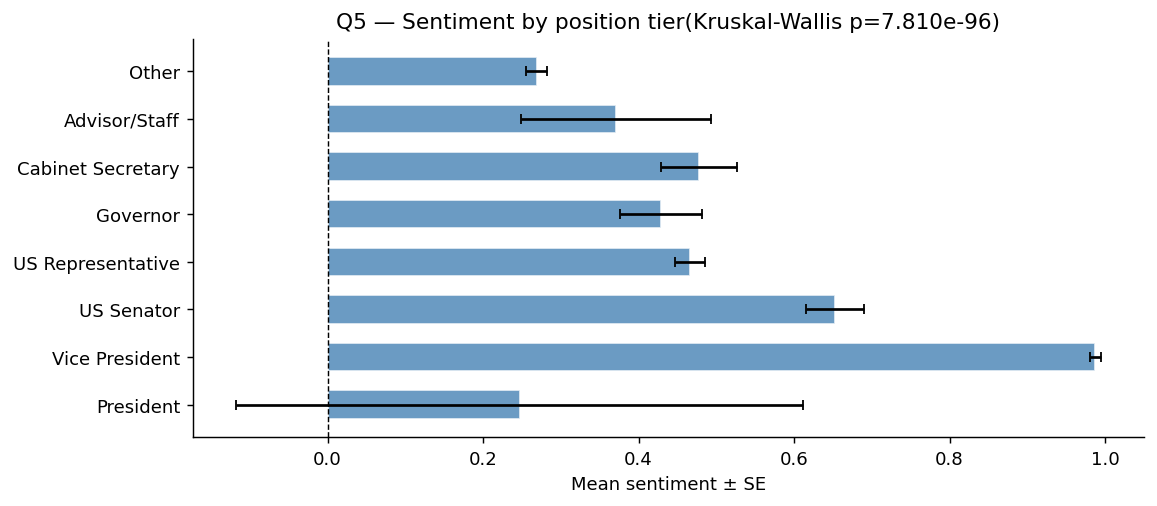

In [9]:
def simplify_position(pos):
    if pos is None: return "Other"
    p = pos.lower()
    if "president of the united states" in p and "vice" not in p        and "advisor" not in p and "senior" not in p: return "President"
    if "vice president" in p:        return "Vice President"
    if "united states senator" in p or ("senator" in p and "state senator" not in p):
        return "US Senator"
    if "united states representative" in p or "member of the united states house" in p:
        return "US Representative"
    if "governor" in p and "lieutenant" not in p: return "Governor"
    if "secretary" in p:             return "Cabinet Secretary"
    if "ambassador" in p:            return "Ambassador"
    if "mayor" in p:                 return "Mayor"
    if "advisor" in p or "counsel" in p or "director" in p: return "Advisor/Staff"
    return "Other"

df["position_simple"] = df["position"].apply(simplify_position)

tiers  = ["President","Vice President","US Senator","US Representative",
          "Governor","Cabinet Secretary","Advisor/Staff","Other"]
groups = [df[df["position_simple"] == t]["sentiment_score"].dropna() for t in tiers]
groups_valid = [(t, g) for t, g in zip(tiers, groups) if len(g) >= 5]

h_stat, h_p = stats.kruskal(*[g for _, g in groups_valid])
print("=== Q5: Sentiment by position tier ===")
print(f"{'Position':25s}  {'n':>5}  {'mean':>7}  {'median':>8}")
for t, g in groups_valid:
    print(f"  {t:23s}  {len(g):5d}  {g.mean():7.4f}  {g.median():8.4f}")
print(f"Kruskal-Wallis: H={h_stat:.3f}  p={h_p:.4e}")

labels_v = [t for t, _ in groups_valid]
means_v  = [g.mean() for _, g in groups_valid]
sems_v   = [g.sem()  for _, g in groups_valid]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(labels_v, means_v, xerr=sems_v, color="steelblue", alpha=0.8,
        edgecolor="white", height=0.6,
        error_kw=dict(ecolor="black", capsize=3))
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean sentiment ± SE")
ax.set_title(f"Q5 — Sentiment by position tier(Kruskal-Wallis p={h_p:.3e})")
plt.tight_layout()
plt.savefig("q5_position_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

In [12]:
print("=== Summary of findings ===")
print()
print("Q1 Neutrality  : mean sentiment is", 
      "≠ 0 (Wikipedia is not fully neutral)" if t_p < 0.05
      else "≈ 0 (Wikipedia appears neutral overall)")
print(f"               : mean={scores.mean():.4f}  p={t_p:.3e}")
print()
print("Q2 Party       : Kruskal-Wallis",
      f"significant (H={h_stat:.2f}, p={h_p:.3e})" if h_p < 0.05
      else f"not significant (p={h_p:.3e})")
print()
print("Q3 Gender      :", "significant difference" if u_p < 0.05
      else "no significant difference",
      f"(Mann-Whitney p={u_p:.3e})")
print()
print("Q4 Centrality  : Spearman ρ =", f"{r_deg:+.3f}",
      f"(p={p_deg:.3e})",
      "significant" if p_deg < 0.05 else "not significant")
print()
print(f"Q5 Position    : Kruskal-Wallis p={h_p:.3e}",
      "significant" if h_p < 0.05 else "not significant")


=== Summary of findings ===

Q1 Neutrality  : mean sentiment is ≠ 0 (Wikipedia is not fully neutral)
               : mean=0.3704  p=2.304e-268

Q2 Party       : Kruskal-Wallis significant (H=462.83, p=7.810e-96)

Q3 Gender      : significant difference (Mann-Whitney p=1.875e-03)

Q4 Centrality  : Spearman ρ = +0.332 (p=1.688e-157) significant

Q5 Position    : Kruskal-Wallis p=7.810e-96 significant
